In [1]:
import h5py
from matplotlib import pyplot as plt

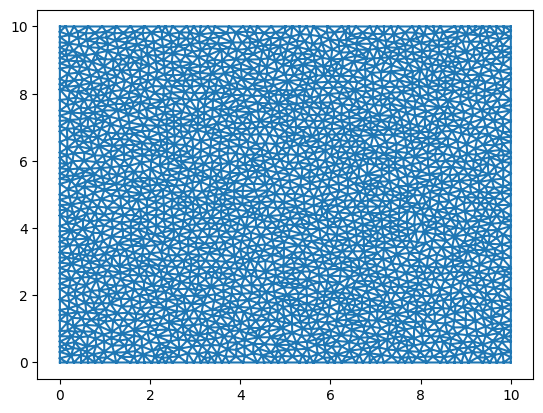

In [2]:
f = h5py.File('steady_state/ref_1/re_vgm_sand_10x10m_2d.h5', 'r')
elements = f['elementsSpatial_Domain0'][:]
nodes = f['nodesSpatial_Domain0'][:]
psi = f['pressure_head_t0'][:]
plt.triplot(nodes[:,0],nodes[:,1],elements)

Text(0.5, 1.0, 'Galerkin')

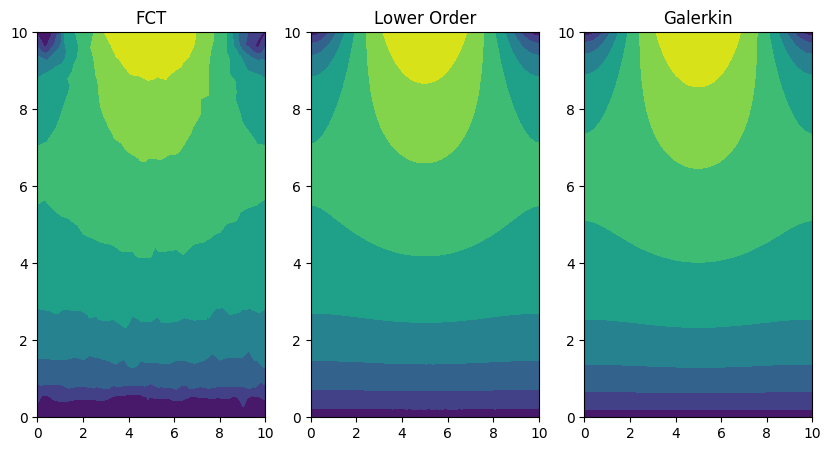

In [3]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10,5))
f_FCT = h5py.File('steady_state/FCT/ref_0/re_vgm_sand_10x10m_2d.h5', 'r')
elements_FCT = f_FCT['elementsSpatial_Domain0'][:]
nodes_FCT = f_FCT['nodesSpatial_Domain0'][:]
psi_FCT = f_FCT['pressure_head_t0'][:]

f2 = h5py.File('steady_state/stab_2/ref_1_new/re_vgm_sand_10x10m_2d.h5', 'r')
elements_2 = f2['elementsSpatial_Domain0'][:]
nodes_2 = f2['nodesSpatial_Domain0'][:]
psi_2 = f2['pressure_head_t0'][:]

fg = h5py.File('steady_state/ref_1/re_vgm_sand_10x10m_2d.h5', 'r')
elements_g = fg['elementsSpatial_Domain0'][:]
nodes_g = fg['nodesSpatial_Domain0'][:]
psi_g = fg['pressure_head_t0'][:]


psi_FCT  = f_FCT['pressure_head_t{0}'.format(201)][:]
psi_2  = f2['pressure_head_t{0}'.format(201)][:]
psi_g = fg['pressure_head_t{0}'.format(201)][:]

ax1.tricontourf(nodes_FCT[:,0],nodes_FCT[:,1],elements_FCT,psi_FCT)
ax2.tricontourf(nodes_2[:,0],nodes_2[:,1],elements_2,psi_2)
tcf3= ax3.tricontourf(nodes_g[:,0],nodes_g[:,1],elements_g,psi_g)

ax1.set_title('FCT')
ax2.set_title('Lower Order')
ax3.set_title('Galerkin')
#fig.colorbar(tcf3, ax= ax3)

## Analytical Solution

In [4]:
import numpy as np
from math import pi, exp, sinh, cos, log, sqrt

def tracy_steady(nodes, *, a, L, alpha, psi_r):
    x = nodes[:, 0]
    z = nodes[:, 1]

    # -------- Parameters --------
    h0 = 1.0 - np.exp(alpha * psi_r)
    beta1 = sqrt((alpha/2)**2 + (2*pi/a)**2)
    psi_ss = np.zeros_like(x)
    for i in range(len(x)):
        xi, zi = x[i], z[i]
        if zi == L: #abs(zi - L) < 1e-12:
            psi_ss[i] = (1/alpha) * np.log(
                np.exp(alpha * psi_r)
                + 0.5 * h0 * (1 - np.cos(2*pi*xi/a))
            )
            continue

        h_bar_ss = (
            0.5 * h0 *
            np.exp(0.5 * alpha * (L - zi)) *
            (
                np.sinh(0.5 * alpha * zi) / np.sinh(0.5 * alpha * L)
                - np.cos(2*pi*xi/a) *
                  np.sinh(beta1 * zi) / np.sinh(beta1 * L)
            )
        )

        # convert transformed variable → psi_ss
        psi_ss[i] = (1/alpha) * np.log(np.exp(alpha * psi_r) + h_bar_ss)

    return psi_ss


In [5]:
psi_ss = tracy_steady(
    nodes,
    a= 10.0,
    L=10.0,
    alpha=0.164,
    psi_r=-15.24
)


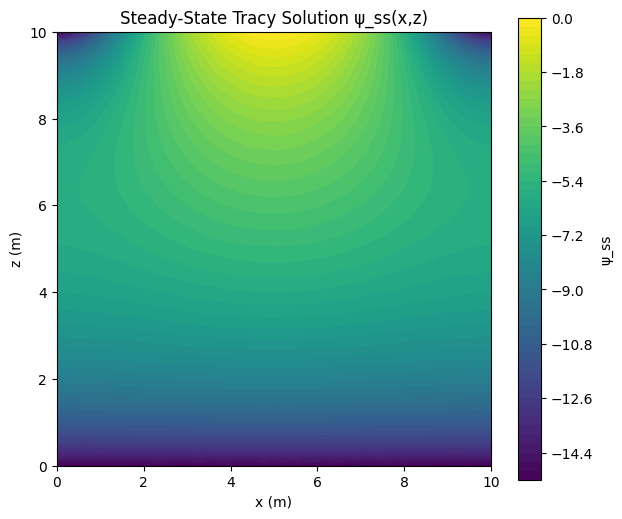

In [6]:
x=nodes[:,0]
z= nodes[:,1]
plt.figure(figsize=(7,6))
tcf = plt.tricontourf(x, z, elements, psi_ss, levels=50) #, cmap='viridis')
plt.colorbar(tcf, label='ψ_ss')
plt.xlabel("x (m)")
plt.ylabel("z (m)")
plt.title("Steady-State Tracy Solution ψ_ss(x,z)")
plt.gca().set_aspect('equal')
plt.show()


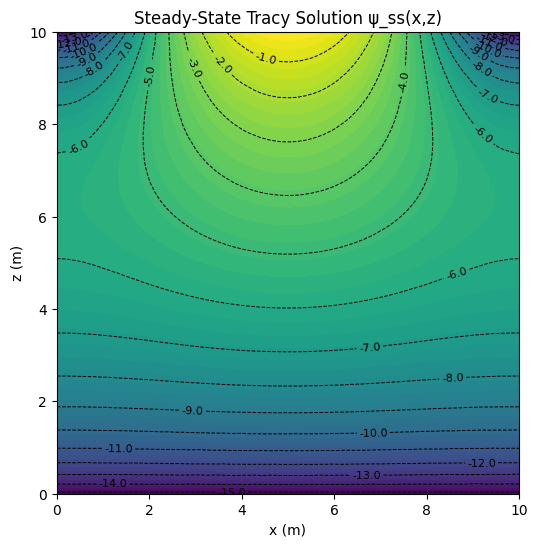

In [7]:
x = nodes[:,0]
z = nodes[:,1]

plt.figure(figsize=(7,6))

# Filled contours
tcf = plt.tricontourf(x, z, elements, psi_ss, levels=50, cmap='viridis')

# Add contour lines
cs = plt.tricontour(
    x, z, elements, psi_ss,
    levels=15,               # number of contour lines
    colors='k',              # black lines
    linewidths=0.7
)

# Label contour lines
plt.clabel(cs, inline=True, fontsize=8, fmt="%.1f")

#plt.colorbar(tcf, label='ψ_ss')
plt.xlabel("x (m)")
plt.ylabel("z (m)")
plt.title("Steady-State Tracy Solution ψ_ss(x,z)")
plt.gca().set_aspect('equal')
plt.savefig("Steady_state_Tracy.png")
#plt.show()


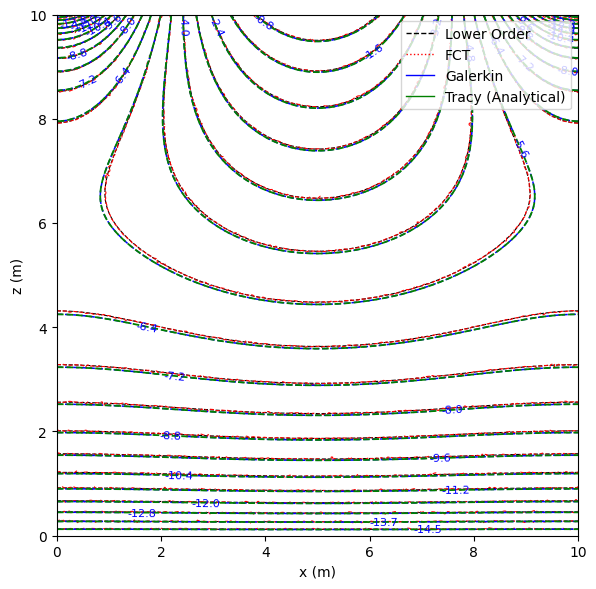

In [8]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

f_FCT = h5py.File('steady_state/FCT/ref_3_again/re_vgm_sand_10x10m_2d.h5', 'r')
nodes_FCT = f_FCT['nodesSpatial_Domain0'][:]
elements_FCT = f_FCT['elementsSpatial_Domain0'][:]
psi_FCT = f_FCT['pressure_head_t{0}'.format(201)][:]

f_LO = h5py.File('steady_state/stab_2/ref_3/re_vgm_sand_10x10m_2d.h5', 'r')
nodes_LO = f_LO['nodesSpatial_Domain0'][:]
elements_LO = f_LO['elementsSpatial_Domain0'][:]
psi_LO = f_LO['pressure_head_t{0}'.format(201)][:]

f_HO = h5py.File('steady_state/ref_3/re_vgm_sand_10x10m_2d.h5', 'r')
nodes_HO = f_HO['nodesSpatial_Domain0'][:]
elements_HO = f_HO['elementsSpatial_Domain0'][:]
psi_HO = f_HO['pressure_head_t{0}'.format(201)][:]

# ---- Compute Tracy steady-state ----
psi_ss = tracy_steady(
    nodes_HO,   # assume same mesh for analytical evaluation
    a=10.0,
    L=10.0,
    alpha=0.164,
    psi_r=-15.24
)

fig, ax = plt.subplots(figsize=(7, 6))

# Consistent contour levels for all numerical + analytical
vmin = min(psi_LO.min(), psi_FCT.min(), psi_HO.min(), psi_ss.min())
vmax = max(psi_LO.max(), psi_FCT.max(), psi_HO.max(), psi_ss.max())
levels = np.linspace(vmin, vmax, 20)

# Lower-order
cs_LO = ax.tricontour(
    nodes_LO[:,0], nodes_LO[:,1], elements_LO, psi_LO,
    levels=levels, colors='black', linewidths=0.8, linestyles='dashed'
)

# FCT
cs_FCT = ax.tricontour(
    nodes_FCT[:,0], nodes_FCT[:,1], elements_FCT, psi_FCT,
    levels=levels, colors='red', linewidths=0.8, linestyles= '--'  #'dotted'
)

# High-order Galerkin
cs_HO = ax.tricontour(
    nodes_HO[:,0], nodes_HO[:,1], elements_HO, psi_HO,
    levels=levels, colors='blue', linewidths=1.1
)
ax.clabel(cs_HO, inline=True, fontsize=8, fmt="%.1f")

# ---- NEW: Analytical Tracy steady-state ----
cs_SS = ax.tricontour(
    nodes_HO[:,0], nodes_HO[:,1], elements_HO, psi_ss,
    levels=levels, colors='green', linewidths=1.3
)

# Appearance
ax.set_aspect("equal")
ax.set_xlabel("x (m)")
ax.set_ylabel("z (m)")

# Legend
from matplotlib.lines import Line2D
ax.legend(
    [
        Line2D([0], [0], color='black', lw=1, linestyle='dashed'),
        Line2D([0], [0], color='red', lw=1, linestyle='dotted'),
        Line2D([0], [0], color='blue', lw=1),
        Line2D([0], [0], color='green', lw=1),
    ],
    ["Lower Order", "FCT", "Galerkin", "Tracy (Analytical)"],
    loc="upper right"
)

plt.tight_layout()
plt.show()


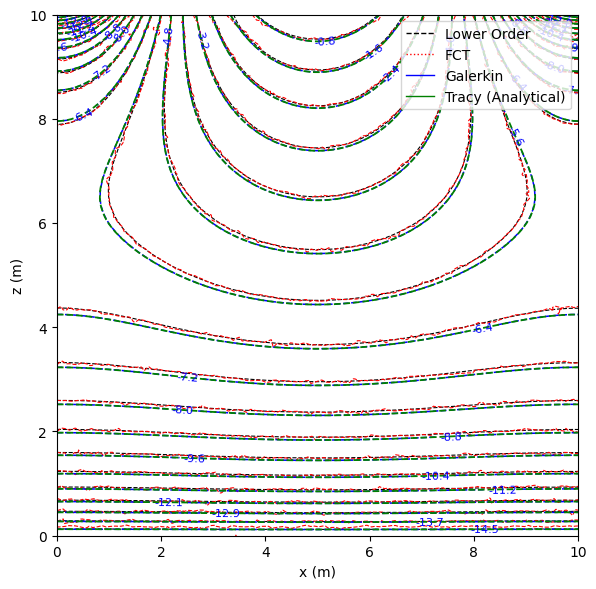

In [9]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

f_FCT = h5py.File('steady_state/FCT/ref_2/re_vgm_sand_10x10m_2d.h5', 'r')
nodes_FCT = f_FCT['nodesSpatial_Domain0'][:]
elements_FCT = f_FCT['elementsSpatial_Domain0'][:]
psi_FCT = f_FCT['pressure_head_t{0}'.format(201)][:]

f_LO = h5py.File('steady_state/stab_2/ref_2/re_vgm_sand_10x10m_2d.h5', 'r')
nodes_LO = f_LO['nodesSpatial_Domain0'][:]
elements_LO = f_LO['elementsSpatial_Domain0'][:]
psi_LO = f_LO['pressure_head_t{0}'.format(201)][:]

f_HO = h5py.File('steady_state/ref_2_new/re_vgm_sand_10x10m_2d.h5', 'r')
nodes_HO = f_HO['nodesSpatial_Domain0'][:]
elements_HO = f_HO['elementsSpatial_Domain0'][:]
psi_HO = f_HO['pressure_head_t{0}'.format(201)][:]

# ---- Compute Tracy steady-state ----
psi_ss = tracy_steady(
    nodes_HO,   # assume same mesh for analytical evaluation
    a=10.0,
    L=10.0,
    alpha=0.164,
    psi_r=-15.24
)

fig, ax = plt.subplots(figsize=(7, 6))

# Consistent contour levels for all numerical + analytical
vmin = min(psi_LO.min(), psi_FCT.min(), psi_HO.min(), psi_ss.min())
vmax = max(psi_LO.max(), psi_FCT.max(), psi_HO.max(), psi_ss.max())
levels = np.linspace(vmin, vmax, 20)

# Lower-order
cs_LO = ax.tricontour(
    nodes_LO[:,0], nodes_LO[:,1], elements_LO, psi_LO,
    levels=levels, colors='black', linewidths=0.8, linestyles='dashed'
)

# FCT
cs_FCT = ax.tricontour(
    nodes_FCT[:,0], nodes_FCT[:,1], elements_FCT, psi_FCT,
    levels=levels, colors='red', linewidths=0.8, linestyles= '--'  #'dotted'
)

# High-order Galerkin
cs_HO = ax.tricontour(
    nodes_HO[:,0], nodes_HO[:,1], elements_HO, psi_HO,
    levels=levels, colors='blue', linewidths=1.1
)
ax.clabel(cs_HO, inline=True, fontsize=8, fmt="%.1f")

# ---- NEW: Analytical Tracy steady-state ----
cs_SS = ax.tricontour(
    nodes_HO[:,0], nodes_HO[:,1], elements_HO, psi_ss,
    levels=levels, colors='green', linewidths=1.3
)

# Appearance
ax.set_aspect("equal")
ax.set_xlabel("x (m)")
ax.set_ylabel("z (m)")

# Legend
from matplotlib.lines import Line2D
ax.legend(
    [
        Line2D([0], [0], color='black', lw=1, linestyle='dashed'),
        Line2D([0], [0], color='red', lw=1, linestyle='dotted'),
        Line2D([0], [0], color='blue', lw=1),
        Line2D([0], [0], color='green', lw=1),
    ],
    ["Lower Order", "FCT", "Galerkin", "Tracy (Analytical)"],
    loc="upper right"
)

plt.tight_layout()
plt.savefig("Steady_state_Tracy_comparison.png")
plt.show()



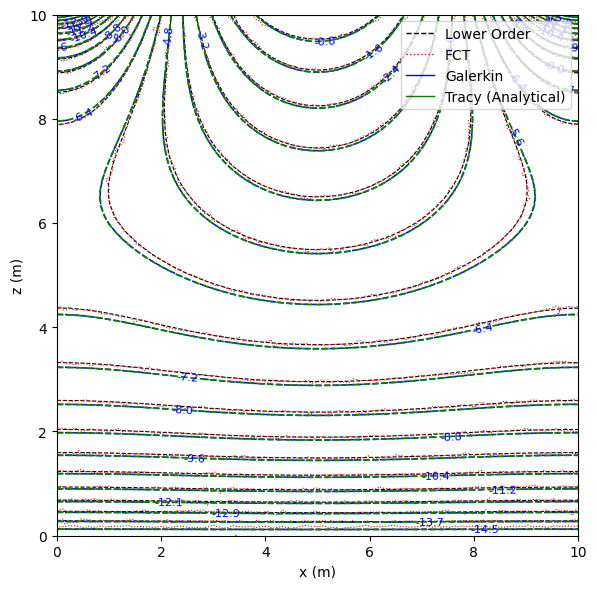

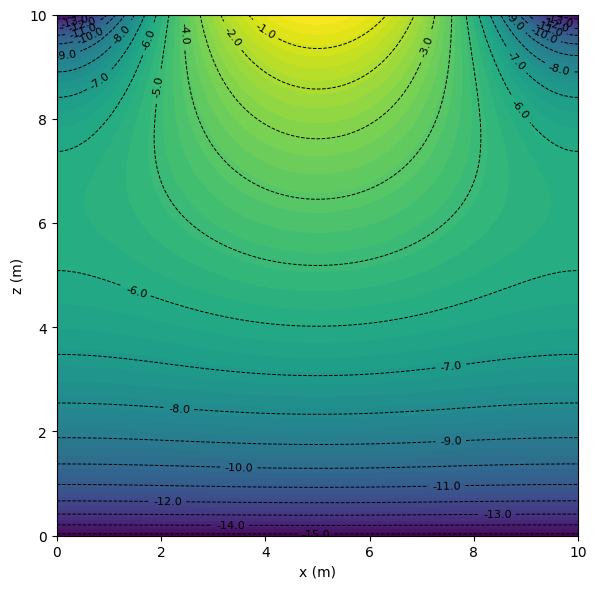

In [10]:
# ==== FIRST FIGURE ====
fig, ax = plt.subplots(figsize=(7, 6))     # <--- unified figsize

# Consistent contour levels
vmin = min(psi_LO.min(), psi_FCT.min(), psi_HO.min(), psi_ss.min())
vmax = max(psi_LO.max(), psi_FCT.max(), psi_HO.max(), psi_ss.max())
levels = np.linspace(vmin, vmax, 20)

# Lower-order
cs_LO = ax.tricontour(
    nodes_LO[:,0], nodes_LO[:,1], elements_LO, psi_LO,
    levels=levels, colors='black', linewidths=0.8, linestyles='dashed'
)

# FCT
cs_FCT = ax.tricontour(
    nodes_FCT[:,0], nodes_FCT[:,1], elements_FCT, psi_FCT,
    levels=levels, colors='red', linewidths=0.8, linestyles='dotted'
)

# High-order Galerkin
cs_HO = ax.tricontour(
    nodes_HO[:,0], nodes_HO[:,1], elements_HO, psi_HO,
    levels=levels, colors='blue', linewidths=1.1
)
ax.clabel(cs_HO, inline=True, fontsize=8, fmt="%.1f")

# Analytical Tracy steady
cs_SS = ax.tricontour(
    nodes_HO[:,0], nodes_HO[:,1], elements_HO, psi_ss,
    levels=levels, colors='green', linewidths=1.3
)

ax.set_aspect("equal")
ax.set_xlabel("x (m)")
ax.set_ylabel("z (m)")

from matplotlib.lines import Line2D
ax.legend(
    [
        Line2D([0], [0], color='black', lw=1, linestyle='dashed'),
        Line2D([0], [0], color='red', lw=1, linestyle='dotted'),
        Line2D([0], [0], color='blue', lw=1),
        Line2D([0], [0], color='green', lw=1),
    ],
    ["Lower Order", "FCT", "Galerkin", "Tracy (Analytical)"],
    loc="upper right"
)

plt.tight_layout()
plt.savefig("Steady_state_Tracy_comparison.png")
plt.show()


# ==== SECOND FIGURE (same figsize) ====
plt.figure(figsize=(7, 6))     # <--- unified figsize

x = nodes_HO[:,0]
z = nodes_HO[:,1]

# Filled contour
tcf = plt.tricontourf(x, z, elements_HO, psi_ss, levels=50, cmap='viridis')

# Contour lines
cs = plt.tricontour(
    x, z, elements_HO, psi_ss,
    levels=15,
    colors='k',
    linewidths=0.7
)
plt.clabel(cs, inline=True, fontsize=8, fmt="%.1f")

plt.xlabel("x (m)")
plt.ylabel("z (m)")
#plt.title("Steady-State Tracy Solution ψ_ss(x, z)")
plt.gca().set_aspect("equal")

plt.tight_layout()
plt.savefig("Steady_state_Tracy.png")
plt.show()


In [11]:
import numpy as np
import quadpy
from math import pi, sinh, cos, log, sqrt


# ----------------------------------------------------------------------
# Internal helpers: precompute Tracy parameters and evaluate vectorized
# ----------------------------------------------------------------------
def _tracy_precompute_params(t_days,
                             a, L, alpha, psi_r,
                             theta_s, theta_r, Ks_day,
                             n_terms):
    """
    Precompute all t- and mode-dependent quantities for Tracy solution.
    Called once per (t_days, params) instead of per quadrature point.
    """
    # basic parameters
    h0 = 1.0 - np.exp(alpha * psi_r)        # \bar h_0
    Ks = Ks_day / 86400.0                   # m/s
    c  = alpha * (theta_s - theta_r) / Ks   # 1/s
    t  = t_days * 86400.0                   # s

    # eigenvalues and decay rates
    k_idx  = np.arange(1, n_terms + 1, dtype=float)  # k = 1..n_terms
    lam    = k_idx * pi / L                          # λ_k
    gamma1 = (lam**2 + (alpha**2) / 4.0) / c         # γ_1
    gamma2 = ((2.0 * pi / a)**2 + lam**2 + (alpha**2) / 4.0) / c  # γ_2

    # mode coefficients that depend on t but not on x,z
    sign = (-1.0) ** k_idx
    A = sign * lam * (1.0 / gamma1) * np.exp(-gamma1 * t)  # for first part
    B = sign * lam * (1.0 / gamma2) * np.exp(-gamma2 * t)  # for second part

    # steady-state root
    root_ss = sqrt((alpha / 2.0)**2 + (2.0 * pi / a)**2)

    return {
        "h0": h0,
        "Ks": Ks,
        "c": c,
        "t": t,
        "lam": lam,
        "A": A,
        "B": B,
        "root_ss": root_ss,
        "alpha": alpha,
        "psi_r": psi_r,
        "a": a,
        "L": L,
    }





def _tracy_eval_steady(nodes, params):
    """
    Steady-state Tracy solution psi_ss(x,z).
    Uses only the steady transformed part \bar h_ss (no transient term).
    """
    x = nodes[:, 0]
    z = nodes[:, 1]

    h0      = params["h0"]
    root_ss = params["root_ss"]
    alpha   = params["alpha"]
    psi_r   = params["psi_r"]
    a       = params["a"]
    L       = params["L"]

    psi_ss = np.empty_like(x)

    # top boundary z = L: same BC formula as transient (time-independent)
    top_mask = np.abs(z - L) < 1e-12
    interior_mask = ~top_mask

    if np.any(top_mask):
        x_top = x[top_mask]
        psi_ss[top_mask] = (1.0 / alpha) * np.log(
            np.exp(alpha * psi_r)
            + 0.5 * h0 * (1.0 - np.cos(2.0 * np.pi * x_top / a))
        )

    if np.any(interior_mask):
        xi = x[interior_mask]
        zi = z[interior_mask]

        exp_factor    = np.exp(0.5 * alpha * (L - zi))
        sinh_alpha_zi = np.sinh(0.5 * alpha * zi)
        sinh_alpha_L  = np.sinh(0.5 * alpha * L)
        cos_x         = np.cos(2.0 * np.pi * xi / a)
        sinh_root_zi  = np.sinh(root_ss * zi)
        sinh_root_L   = np.sinh(root_ss * L)

        h_bar_ss = (
            0.5 * h0
            * exp_factor
            * (
                sinh_alpha_zi / sinh_alpha_L
                - cos_x * (sinh_root_zi / sinh_root_L)
            )
        )

        # Back-transform to psi_ss
        psi_ss[interior_mask] = (1.0 / alpha) * np.log(
            np.exp(alpha * psi_r) + h_bar_ss
        )

    return psi_ss

def tracy_steady_L2_Linf_error_quadpy(u_num,
                                      nodes,
                                      elements,
                                      *,
                                      a, L, alpha, psi_r,
                                      theta_s, theta_r, Ks_day,
                                      n_terms=120,
                                      degree=5):

    scheme = quadpy.t2.get_good_scheme(degree)

    tracy_params = _tracy_precompute_params(
        t_days=0.0,
        a=a, L=L, alpha=alpha, psi_r=psi_r,
        theta_s=theta_s, theta_r=theta_r, Ks_day=Ks_day,
        n_terms=n_terms
    )

    L2_total = 0.0
    Linf_total = 0.0

    for elem in elements:
        coords  = nodes[elem]
        coords2 = coords[:, :2]          # (x,z)
        u_loc_num = u_num[elem]

        v0 = coords2[0]
        J  = np.column_stack((coords2[1] - v0, coords2[2] - v0))
        detJ = np.linalg.det(J)
        if abs(detJ) < 1e-30:
            continue
        invJ = np.linalg.inv(J)

        # ---- vertex Linf (like the Poisson code) ----
        u_ex_v = _tracy_eval_steady(coords2, tracy_params)
        local_Linf = float(np.max(np.abs(u_loc_num - u_ex_v)))

        def integrand(x):
            """
            x: shape (2, n_qp) – physical quadrature points in this element.
            Returns (u_num - u_exact)^2 at each quadrature point.
            """
            nonlocal local_Linf

            pts = x.T
            dx = pts - v0[None, :]
            lam12 = dx @ invJ.T          # <-- match Poisson convention
            lam1  = lam12[:, 0]
            lam2  = lam12[:, 1]
            lam0  = 1.0 - lam1 - lam2

            u_num_vals = lam0*u_loc_num[0] + lam1*u_loc_num[1] + lam2*u_loc_num[2]
            u_ex_vals  = _tracy_eval_steady(pts, tracy_params)

            diff = u_num_vals - u_ex_vals
            local_Linf = max(local_Linf, float(np.max(np.abs(diff))))
            return diff**2

        L2_total += scheme.integrate(integrand, coords2)
        Linf_total = max(Linf_total, local_Linf)

    return np.sqrt(L2_total), Linf_total


In [12]:
## Stab_0

In [13]:
import numpy as np
import h5py

Lx = 10.0  # L[0] = 10

# Tracy / soil parameters (same as transient)
a       = 10.0
L       = 10.0
alpha   = 0.164
psi_r   = -15.24
theta_s = 0.301
theta_r = 0.093
Ks_day  = 2.04

# refinement info: (ref_name, nnx)
ref_info = [
    # ("ref_0", 11),
    ("ref_0", 21),
    ("ref_1", 41),
    ("ref_2_new", 81),
    ("ref_3", 161),
    ("ref_4", 321),
]

results = []

for ref_name, nnx in ref_info:
    h5_path = f"steady_state/{ref_name}/re_vgm_sand_10x10m_2d.h5"
    with h5py.File(h5_path, "r") as f:
        elements = f["elementsSpatial_Domain0"][:]
        nodes    = f["nodesSpatial_Domain0"][:]
        psinum   = f["pressure_head_t{0}".format(200)][:]

    # make sure elements are 0-based (safety)
    if elements.min() == 1:
        elements = elements - 1

    # ---- L2 / Linf vs steady Tracy (analytic) ----
    L2, Linf = tracy_steady_L2_Linf_error_quadpy(
        psinum,
        nodes,
        elements,
        a=a,
        L=L,
        alpha=alpha,
        psi_r=psi_r,
        theta_s=theta_s,
        theta_r=theta_r,
        Ks_day=Ks_day,
        n_terms=200,  # can adjust if needed
        degree=5,
    )

    h = Lx / (nnx - 1)
    results.append([ref_name, nnx, h, L2, Linf])

# ---- compute convergence rates based on L2 and Linf ----
rates_L2   = [None]
rates_Linf = [None]

for k in range(1, len(results)):
    hC, EC_L2, EC_Linf = results[k-1][2], results[k-1][3], results[k-1][4]
    hF, EF_L2, EF_Linf = results[k][2],   results[k][3],   results[k][4]

    if EF_L2 > 0.0 and hC > hF:
        p_L2 = np.log(EC_L2 / EF_L2) / np.log(hC / hF)
    else:
        p_L2 = None

    if EF_Linf > 0.0 and hC > hF:
        p_Linf = np.log(EC_Linf / EF_Linf) / np.log(hC / hF)
    else:
        p_Linf = None

    rates_L2.append(p_L2)
    rates_Linf.append(p_Linf)

# ---- pretty print ----
print(f"{'ref':<6} {'nnx':>5} {'h':>10} {'L2 error':>15} {'Linf error':>15} {'p(L2)':>10} {'p(Linf)':>10}")
print("-" * 95)
for (ref_name, nnx, h, L2, Linf), p2, pinf in zip(results, rates_L2, rates_Linf):
    p2_str   = "   -" if p2   is None else f"{p2:10.3f}"
    pinf_str = "   -" if pinf is None else f"{pinf:10.3f}"
    print(f"{nnx:5d} {h:10.4f} {L2:15.6f} {Linf:15.6f} {p2_str} {pinf_str}")


ref      nnx          h        L2 error      Linf error      p(L2)    p(Linf)
-----------------------------------------------------------------------------------------------
   21     0.5000        0.321549        0.666127    -    -
   41     0.2500        0.102234        0.201036      1.653      1.728
   81     0.1250        0.025619        0.098377      1.997      1.031
  161     0.0625        0.005806        0.030870      2.142      1.672
  321     0.0312        0.001443        0.007473      2.009      2.046


In [14]:
#Stab_2


In [15]:
import numpy as np
import h5py

Lx = 10.0  # L[0] = 10

# Tracy / soil parameters (same as transient)
a       = 10.0
L       = 10.0
alpha   = 0.164
psi_r   = -15.24
theta_s = 0.301
theta_r = 0.093
Ks_day  = 2.04

# refinement info: (ref_name, nnx)
ref_info = [
    # ("ref_0", 11),
    ("ref_0", 21),
    ("ref_1_new", 41),
    ("ref_2", 81),
    ("ref_3", 161),
    ("ref_4", 321),
]

results = []

for ref_name, nnx in ref_info:
    h5_path = f"steady_state/stab_2/{ref_name}/re_vgm_sand_10x10m_2d.h5"
    with h5py.File(h5_path, "r") as f:
        elements = f["elementsSpatial_Domain0"][:]
        nodes    = f["nodesSpatial_Domain0"][:]
        psinum   = f["pressure_head_t{0}".format(200)][:]

    # make sure elements are 0-based (safety)
    if elements.min() == 1:
        elements = elements - 1

    # ---- L2 / Linf vs steady Tracy (analytic) ----
    L2, Linf = tracy_steady_L2_Linf_error_quadpy(
        psinum,
        nodes,
        elements,
        a=a,
        L=L,
        alpha=alpha,
        psi_r=psi_r,
        theta_s=theta_s,
        theta_r=theta_r,
        Ks_day=Ks_day,
        n_terms=200,  # can adjust if needed
        degree=5,
    )

    h = Lx / (nnx - 1)
    results.append([ref_name, nnx, h, L2, Linf])

# ---- compute convergence rates based on L2 and Linf ----
rates_L2   = [None]
rates_Linf = [None]

for k in range(1, len(results)):
    hC, EC_L2, EC_Linf = results[k-1][2], results[k-1][3], results[k-1][4]
    hF, EF_L2, EF_Linf = results[k][2],   results[k][3],   results[k][4]

    if EF_L2 > 0.0 and hC > hF:
        p_L2 = np.log(EC_L2 / EF_L2) / np.log(hC / hF)
    else:
        p_L2 = None

    if EF_Linf > 0.0 and hC > hF:
        p_Linf = np.log(EC_Linf / EF_Linf) / np.log(hC / hF)
    else:
        p_Linf = None

    rates_L2.append(p_L2)
    rates_Linf.append(p_Linf)


print(f"{'ref':<6} {'nnx':>5} {'h':>10} {'L2 error':>15} {'Linf error':>15} {'p(L2)':>10} {'p(Linf)':>10}")
print("-" * 95)
for (ref_name, nnx, h, L2, Linf), p2, pinf in zip(results, rates_L2, rates_Linf):
    p2_str   = "   -" if p2   is None else f"{p2:10.3f}"
    pinf_str = "   -" if pinf is None else f"{pinf:10.3f}"
    print(f"{nnx:5d} {h:10.4f} {L2:15.6f} {Linf:15.6f} {p2_str} {pinf_str}")


ref      nnx          h        L2 error      Linf error      p(L2)    p(Linf)
-----------------------------------------------------------------------------------------------
   21     0.5000        2.750627        0.877996    -    -
   41     0.2500        1.521999        0.310903      0.854      1.498
   81     0.1250        0.730064        0.157298      1.060      0.983
  161     0.0625        0.392262        0.099544      0.896      0.660
  321     0.0312        0.194594        0.045600      1.011      1.126


In [16]:
# FCT

In [17]:
import numpy as np
import h5py

Lx = 10.0  # L[0] = 10

# Tracy / soil parameters (same as transient)
a       = 10.0
L       = 10.0
alpha   = 0.164
psi_r   = -15.24
theta_s = 0.301
theta_r = 0.093
Ks_day  = 2.04

# refinement info: (ref_name, nnx)
ref_info = [
    # ("ref_0", 11),
    ("ref_0", 21),
    ("ref_1", 41),
    ("ref_2", 81),
    ("ref_3_again", 161),
    #("ref_4", 321),
]

results = []

for ref_name, nnx in ref_info:
    h5_path = f"steady_state/FCT/{ref_name}/re_vgm_sand_10x10m_2d.h5"
    with h5py.File(h5_path, "r") as f:
        elements = f["elementsSpatial_Domain0"][:]
        nodes    = f["nodesSpatial_Domain0"][:]
        psinum   = f["pressure_head_t{0}".format(200)][:]

    # make sure elements are 0-based (safety)
    if elements.min() == 1:
        elements = elements - 1

    # ---- L2 / Linf vs steady Tracy (analytic) ----
    L2, Linf = tracy_steady_L2_Linf_error_quadpy(
        psinum,
        nodes,
        elements,
        a=a,
        L=L,
        alpha=alpha,
        psi_r=psi_r,
        theta_s=theta_s,
        theta_r=theta_r,
        Ks_day=Ks_day,
        n_terms=200,  # can adjust if needed
        degree=5,
    )

    h = Lx / (nnx - 1)
    results.append([ref_name, nnx, h, L2, Linf])

# ---- compute convergence rates based on L2 and Linf ----
rates_L2   = [None]
rates_Linf = [None]

for k in range(1, len(results)):
    hC, EC_L2, EC_Linf = results[k-1][2], results[k-1][3], results[k-1][4]
    hF, EF_L2, EF_Linf = results[k][2],   results[k][3],   results[k][4]

    if EF_L2 > 0.0 and hC > hF:
        p_L2 = np.log(EC_L2 / EF_L2) / np.log(hC / hF)
    else:
        p_L2 = None

    if EF_Linf > 0.0 and hC > hF:
        p_Linf = np.log(EC_Linf / EF_Linf) / np.log(hC / hF)
    else:
        p_Linf = None

    rates_L2.append(p_L2)
    rates_Linf.append(p_Linf)


print(f" {'nnx':>5} {'h':>10} {'L2 error':>15} {'Linf error':>15} {'p(L2)':>10} {'p(Linf)':>10}")
print("-" * 95)
for (ref_name, nnx, h, L2, Linf), p2, pinf in zip(results, rates_L2, rates_Linf):
    p2_str   = "   -" if p2   is None else f"{p2:10.3f}"
    pinf_str = "   -" if pinf is None else f"{pinf:10.3f}"
    print(f"{nnx:5d} {h:10.4f} {L2:15.6f} {Linf:15.6f} {p2_str} {pinf_str}")


   nnx          h        L2 error      Linf error      p(L2)    p(Linf)
-----------------------------------------------------------------------------------------------
   21     0.5000        4.565005        3.498896    -    -
   41     0.2500        2.183308        2.059851      1.064      0.764
   81     0.1250        1.005137        1.432020      1.119      0.524
  161     0.0625        0.486053        0.779546      1.048      0.877
